# AgeLens — 11 Final Reporting and Governed V1 Release Package

This notebook creates the final governed **AgeLens V1 reporting package** after:

- canonical cross-sectional validation and release;
- D-015 mortality authorization;
- D-016 mortality model validation and release.

## Outputs

The notebook creates:

- manuscript-ready cross-sectional and mortality tables;
- a cross-sectional cycle summary figure;
- a mortality hazard-ratio forest plot;
- a final scientific report;
- a provenance and checksum manifest;
- a public-release archive containing aggregate results and reproducibility materials;
- D-017, the final V1 release-package decision.

## Privacy and scope

The release archive does **not** include:

- raw NHANES files;
- interim files;
- participant-level Parquet or CSV files;
- cause-specific mortality analyses.

The archive contains only aggregate results, governed documents, configuration snapshots, scripts, notebook inventory, and figures.


In [1]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
import hashlib
import json
import re
import shutil
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_FOLDER_NAME = "nhanes"
DECISION_ID = "D-017"
RELEASE_DATE = "2026-07-22"
RELEASE_VERSION = "AgeLens V1"
RELEASE_MARKER = (
    "<!-- AGE-LENS V1 FINAL RELEASE PACKAGE 2026-07-22 -->"
)
NOTEBOOK_BUILD = "11-v1-final-release-package"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)

print(f"Notebook build: {NOTEBOOK_BUILD}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"Current working directory: {Path.cwd().resolve()}")


Notebook build: 11-v1-final-release-package
numpy: 2.4.6
pandas: 2.3.3
Current working directory: <PROJECT_ROOT>\notebooks


In [2]:
def find_project_root(
    folder_name: str = PROJECT_FOLDER_NAME,
) -> Path:
    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if candidate.name.lower() == folder_name.lower():
            return candidate

    raise FileNotFoundError(
        f"Could not find a parent folder named '{folder_name}'."
    )


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for chunk in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


def replace_document_field(
    text: str,
    field: str,
    value: str,
) -> str:
    pattern = re.compile(
        rf"(?m)^(\|\s*{re.escape(field)}\s*\|\s*)"
        rf"([^|]*?)(\s*\|)$"
    )

    updated, count = pattern.subn(
        lambda match: (
            f"{match.group(1)}{value}{match.group(3)}"
        ),
        text,
        count=1,
    )

    if count != 1:
        raise RuntimeError(
            f"Could not update document field: {field}"
        )

    return updated


def extract_document_version(text: str) -> str:
    match = re.search(
        r"(?m)^\|\s*Version\s*\|\s*([^|]+?)\s*\|$",
        text,
    )

    if not match:
        raise RuntimeError(
            "Could not extract document version."
        )

    return match.group(1).strip()


def add_revision_row(
    text: str,
    row: str,
) -> str:
    marker = (
        "*This file is a single authoritative document"
    )
    marker_index = text.find(marker)

    if marker_index < 0:
        raise RuntimeError(
            "Authoritative-document marker was not found."
        )

    before = text[:marker_index].rstrip()
    after = text[marker_index:]

    if row in before:
        return text

    return before + "\n" + row + "\n\n" + after


def dataframe_to_markdown(
    frame: pd.DataFrame,
) -> str:
    columns = [str(column) for column in frame.columns]
    header = "| " + " | ".join(columns) + " |"
    separator = (
        "| "
        + " | ".join(["---"] * len(columns))
        + " |"
    )

    rows = []

    for _, row in frame.iterrows():
        values = []

        for value in row:
            if pd.isna(value):
                text = ""
            elif isinstance(
                value,
                (float, np.floating),
            ):
                text = f"{float(value):.6g}"
            else:
                text = str(value)

            values.append(
                text.replace("|", "\\|")
            )

        rows.append(
            "| " + " | ".join(values) + " |"
        )

    return "\n".join(
        [header, separator, *rows]
    )


PROJECT_ROOT = find_project_root()

CONFIG_PATH = (
    PROJECT_ROOT / "configs" / "agelens_config.json"
)
DECISION_LOG_PATH = (
    PROJECT_ROOT / "docs" / "governance" / "Decision_Log.md"
)
MORTALITY_PROTOCOL_PATH = (
    PROJECT_ROOT
    / "docs"
    / "methodology"
    / "Mortality_Analysis_Protocol.md"
)
CANONICAL_REPORT_PATH = (
    PROJECT_ROOT
    / "docs"
    / "methodology"
    / "Canonical_V1_Rebuild_Report.md"
)
MORTALITY_REPORT_PATH = (
    PROJECT_ROOT
    / "docs"
    / "methodology"
    / "Mortality_Model_Validation_Report.md"
)

required_documents = [
    CONFIG_PATH,
    DECISION_LOG_PATH,
    MORTALITY_PROTOCOL_PATH,
    CANONICAL_REPORT_PATH,
    MORTALITY_REPORT_PATH,
]

missing_documents = [
    path
    for path in required_documents
    if not path.exists()
]

if missing_documents:
    raise FileNotFoundError(
        f"Required final-release documents are missing: "
        f"{missing_documents}"
    )

CONFIG = json.loads(
    CONFIG_PATH.read_text(encoding="utf-8")
)

TABLES_ROOT = PROJECT_ROOT / CONFIG["paths"]["tables"]
FIGURES_ROOT = PROJECT_ROOT / CONFIG["paths"]["figures"]
LOGS_ROOT = PROJECT_ROOT / CONFIG["paths"]["logs"]
RESULTS_DOC_ROOT = (
    PROJECT_ROOT / "docs" / "results"
)
RELEASE_ROOT = PROJECT_ROOT / "release"

for path in [
    TABLES_ROOT,
    FIGURES_ROOT,
    LOGS_ROOT,
    RESULTS_DOC_ROOT,
    RELEASE_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

CROSS_SECTIONAL_INPUT = (
    TABLES_ROOT
    / "08_canonical_survey_summary.csv"
)
CROSS_SECTIONAL_FLOW_INPUT = (
    TABLES_ROOT
    / "08_canonical_sample_flow.csv"
)
MORTALITY_INPUT = (
    TABLES_ROOT
    / "10_mortality_exposure_results.csv"
)
MORTALITY_DIAGNOSTICS_INPUT = (
    TABLES_ROOT
    / "10_mortality_model_diagnostics.csv"
)
MORTALITY_PH_INPUT = (
    TABLES_ROOT
    / "10_mortality_ph_diagnostics.csv"
)
MORTALITY_RELEASE_CHECKS_INPUT = (
    TABLES_ROOT
    / "10_mortality_release_checks.csv"
)
MORTALITY_RECONCILIATION_INPUT = (
    TABLES_ROOT
    / "10_mortality_reconciliation.csv"
)

required_inputs = [
    CROSS_SECTIONAL_INPUT,
    CROSS_SECTIONAL_FLOW_INPUT,
    MORTALITY_INPUT,
    MORTALITY_DIAGNOSTICS_INPUT,
    MORTALITY_PH_INPUT,
    MORTALITY_RELEASE_CHECKS_INPUT,
    MORTALITY_RECONCILIATION_INPUT,
]

missing_inputs = [
    path
    for path in required_inputs
    if not path.exists()
]

if missing_inputs:
    raise FileNotFoundError(
        f"Required final-reporting inputs are missing: "
        f"{missing_inputs}"
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Release root: {RELEASE_ROOT}")


Project root: <PROJECT_ROOT>
Release root: <PROJECT_ROOT>\release


## 1. Verify final release prerequisites

In [3]:
release_gates = CONFIG.get(
    "release_gates",
    {},
)

required_true_gates = [
    "canonical_outputs_regenerated",
    "canonical_regression_checks_passed",
    "cross_sectional_v1_results_allowed",
    "mortality_analysis_authorized",
    "mortality_cohort_defined",
    "mortality_models_completed",
    "mortality_model_validation_passed",
    "mortality_results_allowed",
]

for gate in required_true_gates:
    if not release_gates.get(gate, False):
        raise RuntimeError(
            f"Required final-release gate is not open: {gate}"
        )

if CONFIG["governance"].get(
    "open_core_evidence_gaps"
) != []:
    raise RuntimeError(
        "Open Core Evidence Gaps remain."
    )

if CONFIG["governance"].get(
    "mortality_results_release_decision"
) != "D-016":
    raise RuntimeError(
        "D-016 is not recorded as the mortality release decision."
    )

decision_text = DECISION_LOG_PATH.read_text(
    encoding="utf-8"
)

if extract_document_version(decision_text) != "1.9":
    raise RuntimeError(
        "Decision Log must be version 1.9 before D-017."
    )

if "### D-016" not in decision_text:
    raise RuntimeError(
        "D-016 is missing from the Decision Log."
    )

if f"### {DECISION_ID}" in decision_text:
    raise RuntimeError(
        f"{DECISION_ID} already exists."
    )

if RELEASE_MARKER in decision_text:
    raise RuntimeError(
        "The final-release marker already exists."
    )

mortality_release_checks = pd.read_csv(
    MORTALITY_RELEASE_CHECKS_INPUT
)

if not mortality_release_checks[
    "pass"
].astype(bool).all():
    raise RuntimeError(
        "Notebook 10 mortality release checks did not all pass."
    )

print("✅ Final release prerequisites verified.")


✅ Final release prerequisites verified.


## 2. Construct final scientific tables

In [4]:
cross_sectional = pd.read_csv(
    CROSS_SECTIONAL_INPUT
)
sample_flow = pd.read_csv(
    CROSS_SECTIONAL_FLOW_INPUT
)
mortality = pd.read_csv(
    MORTALITY_INPUT
)
mortality_diagnostics = pd.read_csv(
    MORTALITY_DIAGNOSTICS_INPUT
)
mortality_ph = pd.read_csv(
    MORTALITY_PH_INPUT
)
mortality_reconciliation = pd.read_csv(
    MORTALITY_RECONCILIATION_INPUT
)

final_cross_sectional = cross_sectional.loc[
    cross_sectional["measure"].eq(
        "canonical_supplement"
    ),
    [
        "sample",
        "cycle",
        "n",
        "weighted_population_sum",
        "weighted_mean",
        "taylor_se",
        "ci_low_95",
        "ci_high_95",
        "weighted_sd_descriptive",
        "stratum_count",
        "psu_count",
    ],
].copy()

final_cross_sectional["sample_label"] = (
    final_cross_sectional["sample"].map(
        {
            "canonical_full": "Full canonical sample",
            "sensitivity_no_topcode": (
                "No-topcode sensitivity"
            ),
        }
    )
)

final_cross_sectional["cycle_label"] = (
    final_cross_sectional["cycle"].map(
        {
            "2015_2016": "2015–2016",
            "2017_2018": "2017–2018",
        }
    )
)

final_cross_sectional = final_cross_sectional.loc[
    :,
    [
        "sample",
        "sample_label",
        "cycle",
        "cycle_label",
        "n",
        "weighted_population_sum",
        "weighted_mean",
        "taylor_se",
        "ci_low_95",
        "ci_high_95",
        "weighted_sd_descriptive",
        "stratum_count",
        "psu_count",
    ],
]

model_labels = {
    "canonical_exposure_only": (
        "Canonical exposure-only"
    ),
    "canonical_primary_adjusted": (
        "Canonical primary adjusted"
    ),
    "canonical_adjusted_per_sd": (
        "Canonical adjusted, per weighted SD"
    ),
    "sensitivity_no_topcode": (
        "No-topcode sensitivity"
    ),
    "sensitivity_erratum": (
        "Erratum constants sensitivity"
    ),
    "sensitivity_creatinine_plus_0_11": (
        "Creatinine +0.11 mg/dL"
    ),
    "sensitivity_creatinine_plus_0_17": (
        "Creatinine +0.17 mg/dL"
    ),
    "sensitivity_creatinine_plus_0_23": (
        "Creatinine +0.23 mg/dL"
    ),
    "sensitivity_exclude_early_deaths": (
        "Exclude deaths within 12 months"
    ),
}

final_mortality = mortality.loc[
    :,
    [
        "model",
        "sample",
        "exposure",
        "adjusted",
        "term",
        "coefficient",
        "standard_error",
        "p_value",
        "hazard_ratio",
        "ci_low_95",
        "ci_high_95",
    ],
].copy()

final_mortality["model_label"] = (
    final_mortality["model"].map(model_labels)
)

final_mortality["effect_scale"] = np.where(
    final_mortality["model"].eq(
        "canonical_adjusted_per_sd"
    ),
    "Per one weighted SD higher acceleration",
    "Per 5-year higher acceleration",
)

primary_result = final_mortality.loc[
    final_mortality["model"].eq(
        "canonical_primary_adjusted"
    )
].squeeze()

if not isinstance(
    primary_result,
    pd.Series,
):
    raise RuntimeError(
        "Expected exactly one primary mortality result."
    )

primary_ph = mortality_ph.loc[
    mortality_ph["term"].eq(
        "phenoage_acceleration_per_5_years"
    )
]

if len(primary_ph) != 1:
    raise RuntimeError(
        "Expected exactly one primary PH diagnostic."
    )

primary_ph_p = float(
    primary_ph.iloc[0]["p_value"]
)

release_summary = pd.DataFrame(
    [
        {
            "domain": "Cross-sectional",
            "status": "Released",
            "primary_output": (
                "Canonical Supplement Phenotypic Age"
            ),
            "sample_n": int(
                final_cross_sectional.loc[
                    final_cross_sectional[
                        "sample"
                    ].eq("canonical_full"),
                    "n",
                ].sum()
            ),
            "events": np.nan,
            "primary_estimate": np.nan,
            "ci_low_95": np.nan,
            "ci_high_95": np.nan,
            "p_value": np.nan,
        },
        {
            "domain": "All-cause mortality",
            "status": "Released",
            "primary_output": (
                "Adjusted HR per 5-year higher "
                "Phenotypic Age acceleration"
            ),
            "sample_n": int(
                mortality_diagnostics.loc[
                    mortality_diagnostics[
                        "model"
                    ].eq(
                        "canonical_primary_adjusted"
                    ),
                    "n",
                ].iloc[0]
            ),
            "events": int(
                mortality_diagnostics.loc[
                    mortality_diagnostics[
                        "model"
                    ].eq(
                        "canonical_primary_adjusted"
                    ),
                    "events",
                ].iloc[0]
            ),
            "primary_estimate": float(
                primary_result["hazard_ratio"]
            ),
            "ci_low_95": float(
                primary_result["ci_low_95"]
            ),
            "ci_high_95": float(
                primary_result["ci_high_95"]
            ),
            "p_value": float(
                primary_result["p_value"]
            ),
        },
        {
            "domain": "Cause-specific mortality",
            "status": "Not authorized",
            "primary_output": "",
            "sample_n": np.nan,
            "events": np.nan,
            "primary_estimate": np.nan,
            "ci_low_95": np.nan,
            "ci_high_95": np.nan,
            "p_value": np.nan,
        },
    ]
)

display(final_cross_sectional.round(6))
display(
    final_mortality[
        [
            "model_label",
            "effect_scale",
            "hazard_ratio",
            "ci_low_95",
            "ci_high_95",
            "p_value",
        ]
    ].round(6)
)
display(release_summary.round(6))


,sample,sample_label,cycle,cycle_label,n,weighted_population_sum,weighted_mean,taylor_se,ci_low_95,ci_high_95,weighted_sd_descriptive,stratum_count,psu_count
0,canonical_full,Full canonical sample,2015_2016,2015–2016,2645,1.292913e+08,42.140869,0.830376,40.513332,43.768406,21.439843,15,30
5,canonical_full,Full canonical sample,2017_2018,2017–2018,2578,1.302142e+08,43.225918,0.660650,41.931044,44.520791,21.859664,15,30
10,sensitivity_no_topcode,No-topcode sensitivity,2015_2016,2015–2016,2524,1.251893e+08,40.806280,0.780352,39.276791,42.335770,20.389702,15,30
15,sensitivity_no_topcode,No-topcode sensitivity,2017_2018,2017–2018,2427,1.252206e+08,41.615735,0.584285,40.470535,42.760934,20.663278,15,30


,model_label,effect_scale,hazard_ratio,ci_low_95,ci_high_95,p_value
0,Canonical exposure-only,Per 5-year higher acceleration,1.232435,1.185107,1.281652,0.0
1,Canonical primary adjusted,Per 5-year higher acceleration,1.185354,1.128633,1.244926,0.0
2,"Canonical adjusted, per weighted SD",Per one weighted SD higher acceleration,1.284997,1.195360,1.381357,0.0
3,No-topcode sensitivity,Per 5-year higher acceleration,1.179104,1.117874,1.243687,0.0
4,Erratum constants sensitivity,Per 5-year higher acceleration,1.188679,1.130885,1.249426,0.0
5,Creatinine +0.11 mg/dL,Per 5-year higher acceleration,1.185354,1.128633,1.244926,0.0
6,Creatinine +0.17 mg/dL,Per 5-year higher acceleration,1.185354,1.128633,1.244926,0.0
7,Creatinine +0.23 mg/dL,Per 5-year higher acceleration,1.185354,1.128633,1.244926,0.0
8,Exclude deaths within 12 months,Per 5-year higher acceleration,1.176648,1.104732,1.253245,0.0


,domain,status,primary_output,sample_n,events,primary_estimate,ci_low_95,ci_high_95,p_value
0,Cross-sectional,Released,Canonical Supplement Phenotypic Age,5223.0,NaN,NaN,NaN,NaN,NaN
1,All-cause mortality,Released,Adjusted HR per 5-year higher Phenotypic Age a...,4350.0,127.0,1.185354,1.128633,1.244926,0.0
2,Cause-specific mortality,Not authorized,,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Create final figures

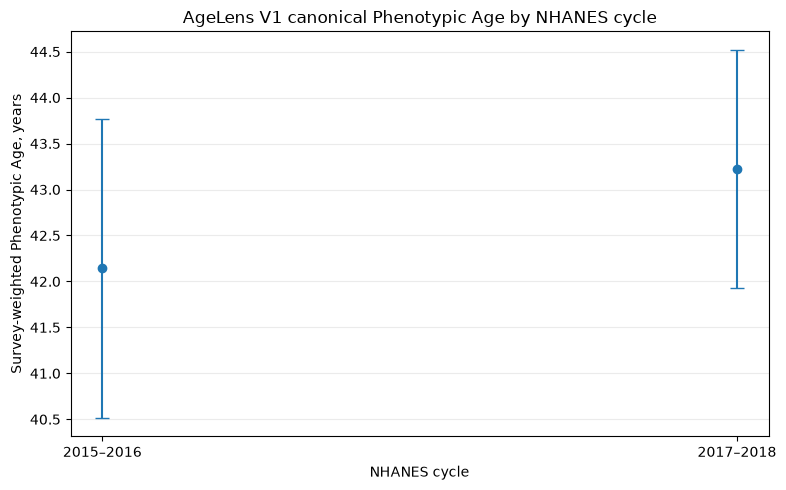

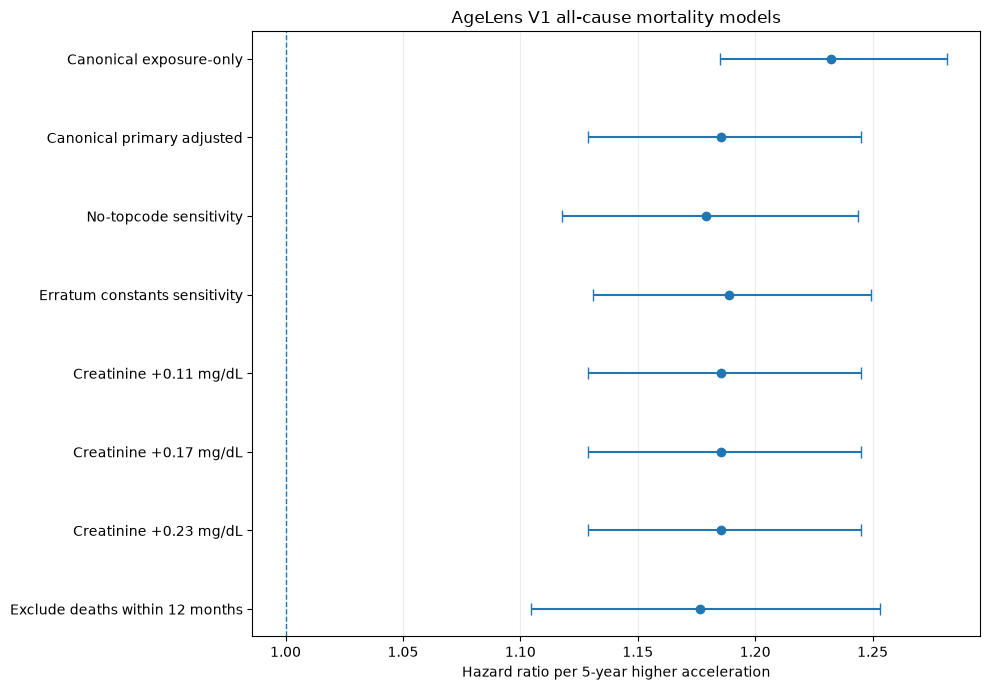

✅ Final figures created.


In [5]:
CROSS_SECTIONAL_FIGURE_PATH = (
    FIGURES_ROOT
    / "11_cross_sectional_cycle_summary.png"
)
MORTALITY_FOREST_PATH = (
    FIGURES_ROOT
    / "11_mortality_forest_plot.png"
)

canonical_cycle = final_cross_sectional.loc[
    final_cross_sectional["sample"].eq(
        "canonical_full"
    )
].sort_values("cycle")

plt.figure(figsize=(8, 5))
plt.errorbar(
    canonical_cycle["cycle_label"],
    canonical_cycle["weighted_mean"],
    yerr=1.96 * canonical_cycle["taylor_se"],
    fmt="o",
    capsize=5,
)
plt.ylabel("Survey-weighted Phenotypic Age, years")
plt.xlabel("NHANES cycle")
plt.title(
    "AgeLens V1 canonical Phenotypic Age by NHANES cycle"
)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    CROSS_SECTIONAL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()

forest_order = [
    "canonical_exposure_only",
    "canonical_primary_adjusted",
    "sensitivity_no_topcode",
    "sensitivity_erratum",
    "sensitivity_creatinine_plus_0_11",
    "sensitivity_creatinine_plus_0_17",
    "sensitivity_creatinine_plus_0_23",
    "sensitivity_exclude_early_deaths",
]

forest = (
    final_mortality.loc[
        final_mortality["model"].isin(
            forest_order
        )
    ]
    .set_index("model")
    .loc[forest_order]
    .reset_index()
)

forest["plot_label"] = (
    forest["model"].map(model_labels)
)

y_positions = np.arange(len(forest))

plt.figure(figsize=(10, 7))
plt.errorbar(
    forest["hazard_ratio"],
    y_positions,
    xerr=np.vstack(
        [
            forest["hazard_ratio"]
            - forest["ci_low_95"],
            forest["ci_high_95"]
            - forest["hazard_ratio"],
        ]
    ),
    fmt="o",
    capsize=4,
)
plt.axvline(
    1.0,
    linestyle="--",
    linewidth=1,
)
plt.yticks(
    y_positions,
    forest["plot_label"],
)
plt.gca().invert_yaxis()
plt.xlabel("Hazard ratio per 5-year higher acceleration")
plt.title(
    "AgeLens V1 all-cause mortality models"
)
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig(
    MORTALITY_FOREST_PATH,
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()

for figure_path in [
    CROSS_SECTIONAL_FIGURE_PATH,
    MORTALITY_FOREST_PATH,
]:
    if not figure_path.exists():
        raise RuntimeError(
            f"Expected figure was not created: {figure_path}"
        )

print("✅ Final figures created.")


## 4. Write final report and governed aggregate tables

In [6]:
FINAL_CROSS_SECTIONAL_PATH = (
    TABLES_ROOT
    / "11_final_cross_sectional_results.csv"
)
FINAL_MORTALITY_PATH = (
    TABLES_ROOT
    / "11_final_mortality_results.csv"
)
RELEASE_SUMMARY_PATH = (
    TABLES_ROOT
    / "11_release_summary.csv"
)
FINAL_REPORT_PATH = (
    RESULTS_DOC_ROOT
    / "AgeLens_V1_Final_Report.md"
)

final_cross_sectional.to_csv(
    FINAL_CROSS_SECTIONAL_PATH,
    index=False,
)
final_mortality.to_csv(
    FINAL_MORTALITY_PATH,
    index=False,
)
release_summary.to_csv(
    RELEASE_SUMMARY_PATH,
    index=False,
)

cross_report = final_cross_sectional.loc[
    :,
    [
        "sample_label",
        "cycle_label",
        "n",
        "weighted_mean",
        "taylor_se",
        "ci_low_95",
        "ci_high_95",
    ],
].copy()

mortality_report = final_mortality.loc[
    :,
    [
        "model_label",
        "effect_scale",
        "hazard_ratio",
        "ci_low_95",
        "ci_high_95",
        "p_value",
    ],
].copy()

primary_hr = float(
    primary_result["hazard_ratio"]
)
primary_ci_low = float(
    primary_result["ci_low_95"]
)
primary_ci_high = float(
    primary_result["ci_high_95"]
)
primary_p = float(
    primary_result["p_value"]
)

report = f"""# AgeLens V1 Final Scientific Report

## Release Status

AgeLens V1 cross-sectional and prespecified all-cause mortality results are released under D-010 through D-017.

Cause-specific mortality remains unauthorized.

## Canonical Specification

- NHANES cycles: 2015–2016 and 2017–2018
- Canonical formula: Supplement conversion pair
- Canonical creatinine policy: observed modern harmonized values
- Missing data: complete-case analysis
- Survey weight: pooled fasting subsample weight `WTSAF4YR`
- Age top-code: retained and flagged, with no-topcode sensitivity
- Open Core Evidence Gaps: none

## Cross-Sectional Results

{dataframe_to_markdown(cross_report.round(6))}

The full canonical survey-weighted mean Phenotypic Age was:

- 42.140869 years in 2015–2016;
- 43.225918 years in 2017–2018.

## Mortality Cohort

- Authorized participants: 4,350
- Observed all-cause deaths: 127
- 2015–2016: 2,178 participants and 83 deaths
- 2017–2018: 2,172 participants and 44 deaths
- Time origin: MEC examination
- Follow-up: public-use `PERMTH_EXM` through 2019

## Primary Mortality Result

The survey-weighted Cox model adjusted for chronological age, sex, race/ethnicity, and NHANES cycle.

Per 5-year higher canonical Phenotypic Age acceleration:

- HR: {primary_hr:.6f}
- 95% CI: {primary_ci_low:.6f} to {primary_ci_high:.6f}
- p-value: {primary_p:.6g}
- proportional-hazards diagnostic p-value: {primary_ph_p:.6g}

## Mortality Models and Sensitivities

{dataframe_to_markdown(mortality_report.round(6))}

The no-topcode, Erratum, creatinine-shift, and early-death-exclusion sensitivities retained the direction and statistical evidence of the primary association.

The three creatinine-shift acceleration models reproduced the canonical acceleration model because the governed shifts are constant additive changes removed by cycle-specific residualization.

## Interpretation

Higher Phenotypic Age acceleration was associated with a higher all-cause mortality hazard during the available public-use follow-up.

The analysis is prognostic and observational. It does not establish that changing Phenotypic Age will causally change mortality risk.

## Limitations

- Public-use mortality follow-up ends in 2019.
- Follow-up is shorter for the 2017–2018 cycle.
- The mortality analysis contains 127 deaths, including 44 in 2017–2018.
- NHANES chronological age is top-coded at 80 years.
- Results use complete cases and fasting-subsample weights.
- Residualized acceleration depends on the governed cycle-specific weighted regression.
- Cause-specific mortality was not analyzed.
- Public-use linked mortality fields and survey weights limit the precision and scope of subgroup analyses.

## Reproducibility

- Canonical regression checks: 29/29 passed.
- Mortality release checks: 22/22 passed.
- Python and R cohort, event, weight, stratum, and PSU summaries reconciled.
- Governance documents and configuration updates were hash-backed up before modification.
- The final release archive excludes raw and participant-level data.

{RELEASE_MARKER}
"""

FINAL_REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(f"Final report: {FINAL_REPORT_PATH}")


Final report: <PROJECT_ROOT>\docs\results\AgeLens_V1_Final_Report.md


## 5. Build the aggregate-only release archive

In [7]:
release_stamp = "20260722"
PACKAGE_ROOT = (
    RELEASE_ROOT
    / f"agelens_v1_release_{release_stamp}"
)
ARCHIVE_PATH = (
    RELEASE_ROOT
    / f"agelens_v1_release_{release_stamp}.zip"
)

if PACKAGE_ROOT.exists():
    raise RuntimeError(
        f"Release package directory already exists: {PACKAGE_ROOT}"
    )

if ARCHIVE_PATH.exists():
    raise RuntimeError(
        f"Release archive already exists: {ARCHIVE_PATH}"
    )

package_directories = [
    PACKAGE_ROOT / "tables",
    PACKAGE_ROOT / "figures",
    PACKAGE_ROOT / "docs",
    PACKAGE_ROOT / "governance",
    PACKAGE_ROOT / "config",
    PACKAGE_ROOT / "scripts",
    PACKAGE_ROOT / "notebook_inventory",
]

for path in package_directories:
    path.mkdir(parents=True, exist_ok=False)

aggregate_table_paths = [
    FINAL_CROSS_SECTIONAL_PATH,
    FINAL_MORTALITY_PATH,
    RELEASE_SUMMARY_PATH,
    TABLES_ROOT / "08_canonical_regression_checks.csv",
    TABLES_ROOT / "10_mortality_release_checks.csv",
    TABLES_ROOT / "10_mortality_reconciliation.csv",
    TABLES_ROOT / "10_mortality_ph_diagnostics.csv",
]

figure_paths = [
    CROSS_SECTIONAL_FIGURE_PATH,
    MORTALITY_FOREST_PATH,
]

document_paths = [
    FINAL_REPORT_PATH,
    CANONICAL_REPORT_PATH,
    MORTALITY_REPORT_PATH,
    MORTALITY_PROTOCOL_PATH,
]

governance_paths = [
    DECISION_LOG_PATH,
    PROJECT_ROOT
    / "docs"
    / "governance"
    / "Evidence_Gap_Register.md",
    PROJECT_ROOT
    / "docs"
    / "governance"
    / "Assumption_Register.md",
]

script_paths = sorted(
    path
    for path in (PROJECT_ROOT / "scripts").glob("*")
    if path.is_file()
    and path.suffix.lower() in {
        ".r",
        ".py",
        ".sh",
        ".ps1",
    }
)

for source in aggregate_table_paths:
    shutil.copy2(
        source,
        PACKAGE_ROOT / "tables" / source.name,
    )

for source in figure_paths:
    shutil.copy2(
        source,
        PACKAGE_ROOT / "figures" / source.name,
    )

for source in document_paths:
    shutil.copy2(
        source,
        PACKAGE_ROOT / "docs" / source.name,
    )

for source in governance_paths:
    if source.exists():
        shutil.copy2(
            source,
            PACKAGE_ROOT / "governance" / source.name,
        )

for source in script_paths:
    shutil.copy2(
        source,
        PACKAGE_ROOT / "scripts" / source.name,
    )

shutil.copy2(
    CONFIG_PATH,
    PACKAGE_ROOT / "config" / CONFIG_PATH.name,
)

notebook_inventory = pd.DataFrame(
    [
        {
            "notebook": path.name,
            "relative_path": str(
                path.relative_to(PROJECT_ROOT)
            ),
            "sha256": sha256_file(path),
        }
        for path in sorted(
            (PROJECT_ROOT / "notebooks").glob("*.ipynb")
        )
        if path.is_file()
    ]
)

NOTEBOOK_INVENTORY_PATH = (
    PACKAGE_ROOT
    / "notebook_inventory"
    / "notebook_inventory.csv"
)
notebook_inventory.to_csv(
    NOTEBOOK_INVENTORY_PATH,
    index=False,
)

package_files = sorted(
    path
    for path in PACKAGE_ROOT.rglob("*")
    if path.is_file()
)

manifest = pd.DataFrame(
    [
        {
            "path": str(
                path.relative_to(PACKAGE_ROOT)
            ),
            "size_bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in package_files
    ]
)

PACKAGE_MANIFEST_PATH = (
    PACKAGE_ROOT / "release_manifest.csv"
)
manifest.to_csv(
    PACKAGE_MANIFEST_PATH,
    index=False,
)

release_readme = f"""# AgeLens V1 Release Package

Release date: 2026-07-22

This archive contains aggregate scientific results, figures, governed documentation, configuration, scripts, notebook inventory, and checksums.

It does not contain raw, interim, or participant-level data.

Primary mortality result:

- HR per 5-year higher Phenotypic Age acceleration: {primary_hr:.6f}
- 95% CI: {primary_ci_low:.6f} to {primary_ci_high:.6f}
- p-value: {primary_p:.6g}

Cause-specific mortality remains unauthorized.
"""

(PACKAGE_ROOT / "README.md").write_text(
    release_readme,
    encoding="utf-8",
)

with zipfile.ZipFile(
    ARCHIVE_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for path in sorted(
        file
        for file in PACKAGE_ROOT.rglob("*")
        if file.is_file()
    ):
        archive.write(
            path,
            arcname=path.relative_to(
                PACKAGE_ROOT.parent
            ),
        )

if not ARCHIVE_PATH.exists():
    raise RuntimeError(
        "The final release archive was not created."
    )

print(f"Release package: {PACKAGE_ROOT}")
print(f"Release archive: {ARCHIVE_PATH}")


Release package: <PROJECT_ROOT>\release\agelens_v1_release_20260722
Release archive: <PROJECT_ROOT>\release\agelens_v1_release_20260722.zip


## 6. Apply D-017 and close the governed V1 release

In [8]:
FINAL_RELEASE_CHECKS_PATH = (
    TABLES_ROOT
    / "11_final_release_checks.csv"
)
FINAL_WRITE_AUDIT_PATH = (
    TABLES_ROOT
    / "11_final_release_write_audit.csv"
)
FINAL_METADATA_PATH = (
    LOGS_ROOT
    / "11_final_reporting_release_metadata.json"
)

final_checks = pd.DataFrame(
    [
        {
            "check": "Cross-sectional release gate is open",
            "pass": bool(
                release_gates[
                    "cross_sectional_v1_results_allowed"
                ]
            ),
        },
        {
            "check": "Mortality release gate is open",
            "pass": bool(
                release_gates[
                    "mortality_results_allowed"
                ]
            ),
        },
        {
            "check": "No Core Evidence Gap remains open",
            "pass": (
                CONFIG["governance"][
                    "open_core_evidence_gaps"
                ]
                == []
            ),
        },
        {
            "check": "Primary mortality estimate is finite",
            "pass": bool(
                np.isfinite(
                    [
                        primary_hr,
                        primary_ci_low,
                        primary_ci_high,
                        primary_p,
                        primary_ph_p,
                    ]
                ).all()
            ),
        },
        {
            "check": "Primary PH diagnostic passes",
            "pass": bool(
                primary_ph_p >= 0.05
            ),
        },
        {
            "check": "Final report exists",
            "pass": FINAL_REPORT_PATH.exists(),
        },
        {
            "check": "Aggregate-only package exists",
            "pass": PACKAGE_ROOT.exists(),
        },
        {
            "check": "Release archive exists",
            "pass": ARCHIVE_PATH.exists(),
        },
        {
            "check": "Participant-level files excluded",
            "pass": not any(
                path.suffix.lower() in {
                    ".parquet",
                    ".xpt",
                    ".dat",
                }
                for path in PACKAGE_ROOT.rglob("*")
                if path.is_file()
            ),
        },
        {
            "check": "Cause-specific mortality remains unauthorized",
            "pass": (
                CONFIG["release_scope"][
                    "cause_specific_mortality"
                ]
                == "not_authorized"
            ),
        },
    ]
)

if not final_checks["pass"].all():
    display(
        final_checks.loc[
            ~final_checks["pass"]
        ]
    )
    raise RuntimeError(
        "Final V1 release checks failed. "
        "Governance files were not updated."
    )

final_checks.to_csv(
    FINAL_RELEASE_CHECKS_PATH,
    index=False,
)

decision_text = replace_document_field(
    decision_text,
    "Version",
    "2.0",
)
decision_text = replace_document_field(
    decision_text,
    "Last Updated",
    RELEASE_DATE,
)
decision_text = add_revision_row(
    decision_text,
    (
        "| 2.0 | 2026-07-22 | Approved D-017: "
        "final AgeLens V1 scientific report, aggregate-only "
        "release package, provenance manifest, and archive. |"
    ),
)

decision_entry = f"""
{RELEASE_MARKER}

---

### D-017

| Field | Value |
| --- | --- |
| Title | Approve the final AgeLens V1 reporting and release package |
| Description | Approve the final cross-sectional and all-cause mortality report, aggregate scientific tables, figures, provenance manifest, notebook inventory, configuration snapshot, reproducibility scripts, and aggregate-only release archive. |
| Related Research Question | RQ1–RQ5 |
| Supporting Evidence | Canonical validation passed 29/29 checks; mortality validation passed 22/22 checks; D-010 through D-016 are approved; no Core Evidence Gap remains open. |
| Evidence Level | Complete governed replication, model validation, and release-package audit |
| Confidence Rating | High for the prespecified AgeLens V1 scope |
| Reviewer | Project owner |
| Status | Approved |
| Date | 2026-07-22 |
| Related Assumptions | D-010 through D-016 |
| Related Evidence Gaps | None blocking V1 release |
| Notes | The archive excludes raw, interim, and participant-level data. Cause-specific mortality remains unauthorized. The primary adjusted mortality HR per 5-year higher acceleration is {primary_hr:.6f} (95% CI {primary_ci_low:.6f}–{primary_ci_high:.6f}; p={primary_p:.6g}). |
"""

decision_text = (
    decision_text.rstrip()
    + "\n\n"
    + decision_entry.strip()
    + "\n"
)

if extract_document_version(decision_text) != "2.0":
    raise RuntimeError(
        "Updated Decision Log version is not 2.0."
    )

if f"### {DECISION_ID}" not in decision_text:
    raise RuntimeError(
        "D-017 was not constructed."
    )

timestamp = datetime.now(
    timezone.utc
).strftime("%Y%m%dT%H%M%SZ")

BACKUP_ROOT = (
    LOGS_ROOT
    / "final_release_backups"
    / timestamp
)
BACKUP_ROOT.mkdir(
    parents=True,
    exist_ok=False,
)

backup_specs = {
    "decision_log": DECISION_LOG_PATH,
    "config": CONFIG_PATH,
}

write_audit_records = []

for artifact, source_path in backup_specs.items():
    backup_path = (
        BACKUP_ROOT / source_path.name
    )
    shutil.copy2(
        source_path,
        backup_path,
    )

    before_hash = sha256_file(
        source_path
    )
    backup_hash = sha256_file(
        backup_path
    )

    if before_hash != backup_hash:
        raise RuntimeError(
            f"Backup hash mismatch for {artifact}."
        )

    write_audit_records.append(
        {
            "artifact": artifact,
            "path": str(
                source_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "backup": str(
                backup_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "sha256_before": before_hash,
            "sha256_backup": backup_hash,
            "sha256_after": "",
        }
    )

DECISION_LOG_PATH.write_text(
    decision_text,
    encoding="utf-8",
)

updated_config = json.loads(
    CONFIG_PATH.read_text(encoding="utf-8")
)

updated_config["project"]["status"] = (
    "agelens_v1_release_package_complete"
)
updated_config["project"][
    "final_scientific_results_allowed"
] = True

updated_config["governance"][
    "final_release_decision"
] = DECISION_ID

updated_config["release_gates"][
    "final_release_package_complete"
] = True
updated_config["release_gates"][
    "final_report_written"
] = True
updated_config["release_gates"][
    "aggregate_release_archive_created"
] = True

updated_config["release_scope"][
    "agelens_v1"
] = "final_release_complete"
updated_config["release_scope"][
    "cause_specific_mortality"
] = "not_authorized"

updated_config["final_release"] = {
    "version": RELEASE_VERSION,
    "decision": DECISION_ID,
    "release_date": RELEASE_DATE,
    "final_report": str(
        FINAL_REPORT_PATH.relative_to(
            PROJECT_ROOT
        )
    ),
    "package_directory": str(
        PACKAGE_ROOT.relative_to(
            PROJECT_ROOT
        )
    ),
    "archive": str(
        ARCHIVE_PATH.relative_to(
            PROJECT_ROOT
        )
    ),
    "aggregate_only": True,
    "participant_level_data_included": False,
    "cause_specific_mortality_authorized": False,
}

CONFIG_PATH.write_text(
    json.dumps(
        updated_config,
        indent=2,
        ensure_ascii=False,
    )
    + "\n",
    encoding="utf-8",
)

for record in write_audit_records:
    source_path = (
        PROJECT_ROOT / record["path"]
    )
    record["sha256_after"] = sha256_file(
        source_path
    )

    if (
        record["sha256_after"]
        == record["sha256_before"]
    ):
        raise RuntimeError(
            f"{record['artifact']} did not change."
        )

write_audit = pd.DataFrame(
    write_audit_records
)
write_audit.to_csv(
    FINAL_WRITE_AUDIT_PATH,
    index=False,
)

archive_sha256 = sha256_file(
    ARCHIVE_PATH
)

metadata = {
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "notebook": (
        "11_final_reporting_and_release_package.ipynb"
    ),
    "release_version": RELEASE_VERSION,
    "decision": DECISION_ID,
    "primary_mortality_result": {
        "hazard_ratio": primary_hr,
        "ci_low_95": primary_ci_low,
        "ci_high_95": primary_ci_high,
        "p_value": primary_p,
        "ph_diagnostic_p_value": primary_ph_p,
    },
    "archive": str(
        ARCHIVE_PATH.relative_to(
            PROJECT_ROOT
        )
    ),
    "archive_sha256": archive_sha256,
    "package_file_count": int(
        sum(
            1
            for path in PACKAGE_ROOT.rglob("*")
            if path.is_file()
        )
    ),
    "participant_level_data_included": False,
    "cause_specific_mortality_authorized": False,
    "backup_root": str(
        BACKUP_ROOT.relative_to(
            PROJECT_ROOT
        )
    ),
}

FINAL_METADATA_PATH.write_text(
    json.dumps(
        metadata,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

display(final_checks)
display(write_audit)

print("✅ D-017 applied.")
print("✅ AgeLens V1 final scientific report completed.")
print("✅ Aggregate-only release archive created.")
print("✅ Final AgeLens V1 release package is complete.")
print("Cause-specific mortality remains unauthorized.")
print(f"Release archive: {ARCHIVE_PATH}")
print(f"Archive SHA-256: {archive_sha256}")
print(f"Configuration backup: {BACKUP_ROOT}")


,check,pass
0,Cross-sectional release gate is open,True
1,Mortality release gate is open,True
2,No Core Evidence Gap remains open,True
3,Primary mortality estimate is finite,True
4,Primary PH diagnostic passes,True
5,Final report exists,True
6,Aggregate-only package exists,True
7,Release archive exists,True
8,Participant-level files excluded,True
9,Cause-specific mortality remains unauthorized,True


,artifact,path,backup,sha256_before,sha256_backup,sha256_after
0,decision_log,docs\governance\Decision_Log.md,logs\final_release_backups\20260722T172115Z\De...,0e6f4ace25e3c8bcbfe1b31ca37f89710515e672e6c990...,0e6f4ace25e3c8bcbfe1b31ca37f89710515e672e6c990...,a9c64ae236df8027297a34d67c289758dbc8d065d538ba...
1,config,configs\agelens_config.json,logs\final_release_backups\20260722T172115Z\ag...,cea65621f9c13ffa4b25dbaa3b1a310abb3fb7cbbb33b2...,cea65621f9c13ffa4b25dbaa3b1a310abb3fb7cbbb33b2...,1ce887babe1d335004eb761711766f6f123338d7ca872b...


✅ D-017 applied.
✅ AgeLens V1 final scientific report completed.
✅ Aggregate-only release archive created.
✅ Final AgeLens V1 release package is complete.
Cause-specific mortality remains unauthorized.
Release archive: <PROJECT_ROOT>\release\agelens_v1_release_20260722.zip
Archive SHA-256: 79c0c5e716c345dcb7cf887b14cd9430fff835bc19504824f04b10c90ec824b3
Configuration backup: <PROJECT_ROOT>\logs\final_release_backups\20260722T172115Z
